In [ ]:
# Strategic Foresight Simulator (UN 2.0)

This notebook builds a Monte Carlo–based scenario simulator to explore
future risks to coastal digital infrastructure under climate uncertainty.

This is an educational and policy-oriented prototype.


In [ ]:
!pip install numpy pandas matplotlib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def run_simulation(
    sea_level_rise,
    extreme_weather_freq,
    infrastructure_resilience,
    digital_dependency,
    adaptation_investment,
    n_simulations=10000
):
    """
    Monte Carlo simulation for digital infrastructure risk.
    All inputs should be between 0 and 1 except sea_level_rise (meters).
    """

    results = []

    for _ in range(n_simulations):
        # Random uncertainty around inputs
        sea_level = np.random.normal(sea_level_rise, 0.1)
        weather = np.random.normal(extreme_weather_freq, 0.05)

        # Ensure values stay realistic
        sea_level = max(sea_level, 0)
        weather = min(max(weather, 0), 1)

        # Risk calculation
        risk = (
            sea_level *
            weather *
            digital_dependency *
            (1 - infrastructure_resilience) *
            (1 - adaptation_investment)
        )

        results.append(risk)

    return np.array(results)

In [ ]:
results = run_simulation(
    sea_level_rise=0.5,
    extreme_weather_freq=0.3,
    infrastructure_resilience=0.6,
    digital_dependency=0.7,
    adaptation_investment=0.4
)

print("Mean Risk:", results.mean())
print("95th Percentile (Worst Case):", np.percentile(results, 95))

Mean Risk: 0.025175283350274077
95th Percentile (Worst Case): 0.03681787544837725


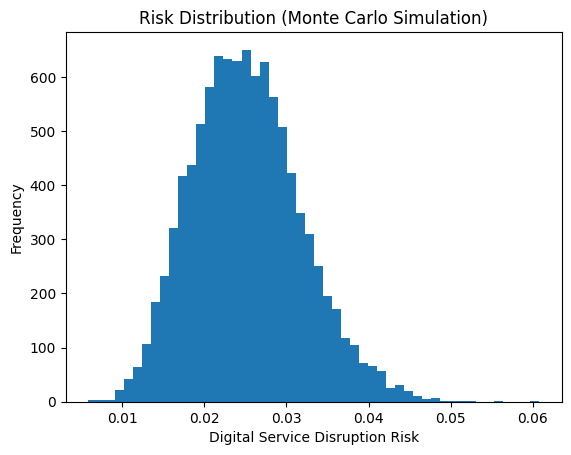

In [ ]:
plt.hist(results, bins=50)
plt.xlabel("Digital Service Disruption Risk")
plt.ylabel("Frequency")
plt.title("Risk Distribution (Monte Carlo Simulation)")
plt.show()